# Global & per-CpG mCG across cell types (Fig 2A–C, S9C)

Part of the **[Fig. 2 chapter](fig2.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


## 📥 Required input files

This notebook reads the following files (paths resolve from `ENTEX_ROOT`/`REF_ROOT`; the setup cell sets them). See the chapter's `inputs.md` for RAW-vs-derived tags.

- `f'{indir}L1color.tsv'`  ·  _metadata: color_
- `f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz'`  ·  _joint summary obj_
- `f'mCG_distribution/multires/{ct}.npy'`  ·  _other_


In [1]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [2]:
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import pysam
import anndata

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [3]:
indir = f'{ENTEX_ROOT}/'


In [4]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop('c7', axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()
L1_color.update({L1_annot[k]: L1_color[k] for k in L1_annot if k in L1_color})  # also key by name
# L1_annot['c35'] = 'Hema Bnaive'
# L1_annot['c7'] = 'Hema Bmem'
# L1_color['c35'] = L1_color['c7']


In [5]:
# Public cell metadata (5kCG100k3C_summary.csv.gz): majortype=L1, subtype->subtype_meta, cluster=L2_final
meta = pd.read_csv(f'{indir}clustering/merged/5kCG100k3C_summary.csv.gz', index_col=0)
meta['L1'] = meta['majortype']   # adapter: public column name -> the name used below
meta.columns

## Generate multi-resolution mCG histograms (cached)

Produces `mCG_distribution/multires/{ct}.npy`, read by `fig2/02`, `fig3/02`, `fig3/08`. Cache-guarded: skipped when the files already exist.


In [6]:
def multires_cghist(ct):
    result = np.zeros((len(reslist), nbins))
    allc_path = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.allc.tsv.gz'
    for chrom in chrom_sizes.index:
        npos = (chrom_sizes[chrom] // reslist[-1] * reslist[-1])
        data = []
        # with gzip.open(allc_path, 'rt') as allc_lines:
        with pysam.TabixFile(allc_path) as allc:
            allc_lines = allc.fetch(chrom)
            for line in allc_lines:
                _, pos, _, context, mc, cov, *_ = line.split("\t")
                data.append([pos, mc, cov])
        data = pd.DataFrame(data, columns=['pos', 'mc', 'cov']).astype(int)
        posfilter = np.ones(data.shape[0]).astype(bool)
        for bed in rm_list:
            for xx,yy in bed[chrom]:
                posfilter[np.logical_and(data['pos']>=xx, data['pos']<=yy)] = False
        data = data.loc[posfilter & (data['pos'] < npos)]
        data_mc = csr_matrix((data['mc'], (np.zeros(data.shape[0]), data['pos']-1)), shape=[1, npos])
        data_cov = csr_matrix((data['cov'], (np.zeros(data.shape[0]), data['pos']-1)), shape=[1, npos])
        data_multires_hist = []
        for i,res in enumerate(reslist):
            tmp = data_mc.reshape((-1, res)).sum(axis=1).A1 / data_cov.reshape((-1, res)).sum(axis=1).A1
            tmp = tmp[~np.isnan(tmp)]
            tmp = np.histogram(tmp, bins=nbins, range=(0,1))[0]
            result[i] += tmp
        # print(chrom)
    # result = pd.DataFrame(result, index=reslist)
    np.save(f'mCG_distribution/multires/{ct}.npy', result)
    return result
    

In [7]:
import os
# Generate multi-resolution mCG histograms -> mCG_distribution/multires/{ct}.npy
# (cached; read by fig2/02, fig3/02, fig3/08). Runs only if missing.
REGENERATE = False
if REGENERATE or not any(os.path.exists(f'mCG_distribution/multires/{ct}.npy') for ct in L1_annot):
    from concurrent.futures import ProcessPoolExecutor, as_completed
    
    cpu = 20
    with ProcessPoolExecutor(cpu) as executor:
        futures = {}
        for ct in L1_meta.index:
            future = executor.submit(
                multires_cghist,
                ct=ct,
            )
            futures[future] = ct
    
        result = {}
        for future in as_completed(futures):
            ct = futures[future]
            result[ct] = future.result()
            print(f'{ct} finished')
else:
    print('[cached] multires/*.npy present, skipping generation')


In [8]:
L1_list = meta.groupby('L1')['mCGFrac'].median().sort_values().index


In [9]:
donor_palette = {xx:yy for xx,yy in zip(meta['Donor'].unique(), sns.color_palette('tab20', 20))}


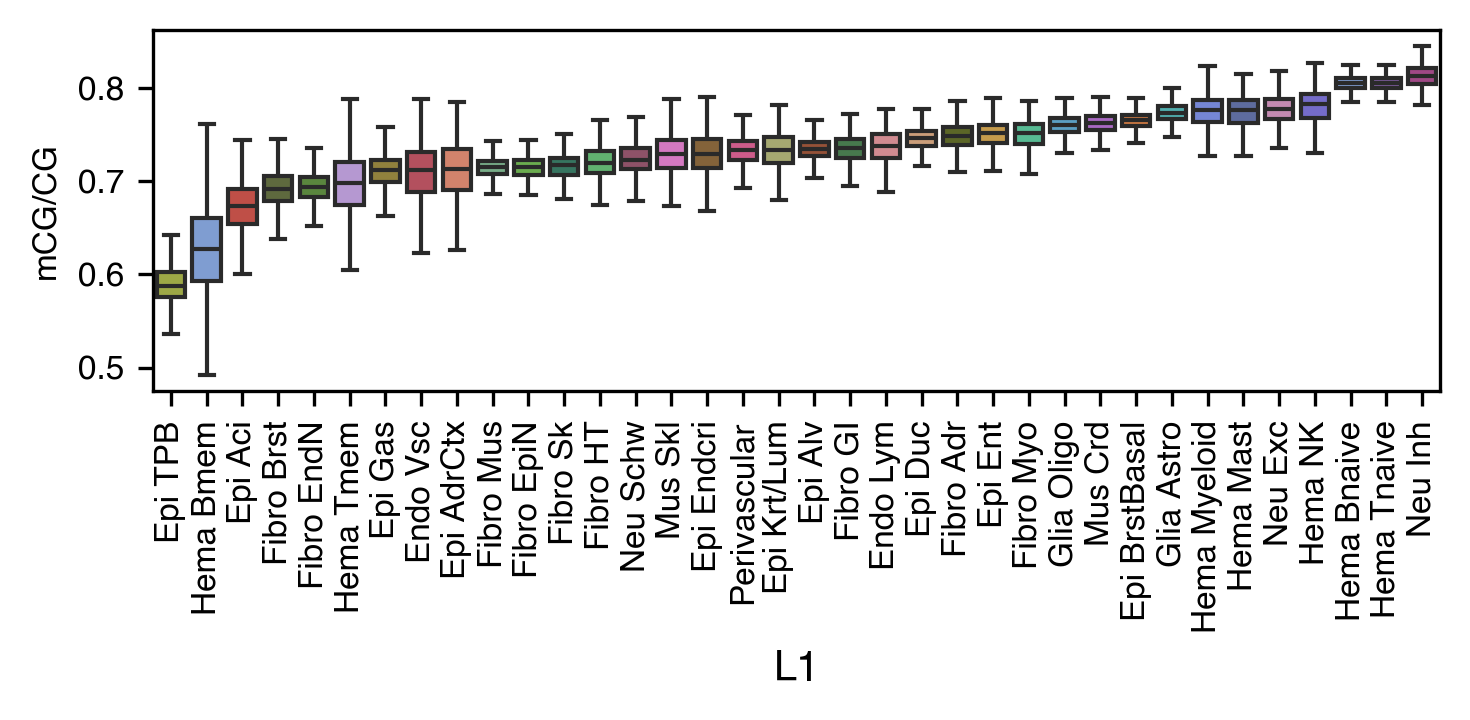

In [10]:
fig, ax = plt.subplots(figsize=(5,2.5), dpi=300)
sns.boxplot(data=meta, x='L1', y='mCGFrac', hue='L1', ax=ax, 
            palette=L1_color, order=L1_list, showfliers=False)
ax.set_xticks(np.arange(len(L1_list)))
ax.set_xticklabels(L1_list.map(L1_annot), fontsize=8, rotation=90)
ax.set_yticks(np.arange(0.5, 0.81, 0.1))
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
ax.set_ylabel('mCG/CG', fontsize=8)
# ax.get_legend().set_visible(False)
fig.tight_layout()
fig.savefig('mCG_distribution/L1_cellglobalCG_box.pdf', transparent=True)


In [11]:
L1_meta = L1_meta.drop(['c35','c36'], axis=0)


In [12]:
import pyBigWig

ratio = []
for ct in L1_meta.index:
    bw_file = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.frac.bw'
    bw = pyBigWig.open(bw_file)
    info = bw.header()
    ratio.append([info['sumData']/info['nBasesCovered'], 
                  meta.loc[meta['L1']==ct, 'mCGFrac'].mean()])
    
ratio = pd.DataFrame(ratio, index=L1_meta.index, columns=['site_ave', 'cell_ave'])


In [13]:
import cooler
chrom_size_path = '/large_experiments/zhoulab/ref/hg38/fasta/hg38.main.chrom.sizes'
chrom_sizes = cooler.read_chromsizes(chrom_size_path, all_names=True)
chrom_sizes = chrom_sizes.iloc[:22]


In [14]:
rm_list = []
for bed_path in [f'{REF_ROOT}/hg38/fasta/hg38.altseq.bed', f'{REF_ROOT}/blacklist/hg38-blacklist.v2.bed.gz']:
    bed = pd.read_csv(bed_path, sep='\t', header=None, index_col=None)
    bed = {chrom:bed.loc[bed[0]==chrom, [1,2]].values for chrom in chrom_sizes.index}
    rm_list.append(bed)
    

In [15]:
nbins = 100
reslist = [1, 5, 10, 50, 100, 500, 1000, 5000, 10000, 50000]


In [16]:
def multires_cghist(ct):
    result = np.zeros((len(reslist), nbins))
    allc_path = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.allc.tsv.gz'
    for chrom in chrom_sizes.index:
        npos = (chrom_sizes[chrom] // reslist[-1] * reslist[-1])
        data = []
        # with gzip.open(allc_path, 'rt') as allc_lines:
        with pysam.TabixFile(allc_path) as allc:
            allc_lines = allc.fetch(chrom)
            for line in allc_lines:
                _, pos, _, context, mc, cov, *_ = line.split("\t")
                data.append([pos, mc, cov])
        data = pd.DataFrame(data, columns=['pos', 'mc', 'cov']).astype(int)
        posfilter = np.ones(data.shape[0]).astype(bool)
        for bed in rm_list:
            for xx,yy in bed[chrom]:
                posfilter[np.logical_and(data['pos']>=xx, data['pos']<=yy)] = False
        data = data.loc[posfilter & (data['pos'] < npos)]
        data_mc = csr_matrix((data['mc'], (np.zeros(data.shape[0]), data['pos']-1)), shape=[1, npos])
        data_cov = csr_matrix((data['cov'], (np.zeros(data.shape[0]), data['pos']-1)), shape=[1, npos])
        data_multires_hist = []
        for i,res in enumerate(reslist):
            tmp = data_mc.reshape((-1, res)).sum(axis=1).A1 / data_cov.reshape((-1, res)).sum(axis=1).A1
            tmp = tmp[~np.isnan(tmp)]
            tmp = np.histogram(tmp, bins=nbins, range=(0,1))[0]
            result[i] += tmp
        # print(chrom)
    # result = pd.DataFrame(result, index=reslist)
    np.save(f'mCG_distribution/multires/{ct}.npy', result)
    return result
    

In [17]:
from concurrent.futures import ProcessPoolExecutor, as_completed

cpu = 20
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for ct in L1_meta.index:
        future = executor.submit(
            multires_cghist,
            ct=ct,
        )
        futures[future] = ct

    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')


In [18]:
L1_meta = L1_meta.drop(['c7'], axis=0)


In [19]:
result = {ct:np.load(f'mCG_distribution/multires/{ct}.npy') for ct in L1_meta.index}
data = pd.DataFrame([(result[ct]/result[ct].sum(axis=1)[:,None]).flatten() for ct in L1_meta.index], index=L1_meta.index)
data = (data.T / data.sum(axis=1)) * 1e6


In [20]:
leg_order = pd.Index(['c2', 'c35', 
                      'c22', 'c1', 'c3', 'c9', 
                      'c17', 'c32', 'c19', 'c4', 
                      'c23', 'c28', 'c21', 'c12', 'c6', 'c11', 'c13', 'c5', 'c29', 'c18', 
                      'c26', 'c20', 'c30', 'c33', 'c8', 'c34', 
                      'c10', 'c31', 'c14', 'c25', 'c27', 'c24', 'c0', 'c15', 'c36', 'c16'])

In [21]:
data = pd.DataFrame([result[ct][0] for ct in L1_meta.index], index=L1_meta.index)
data = (data.T / data.sum(axis=1)) * 1e6


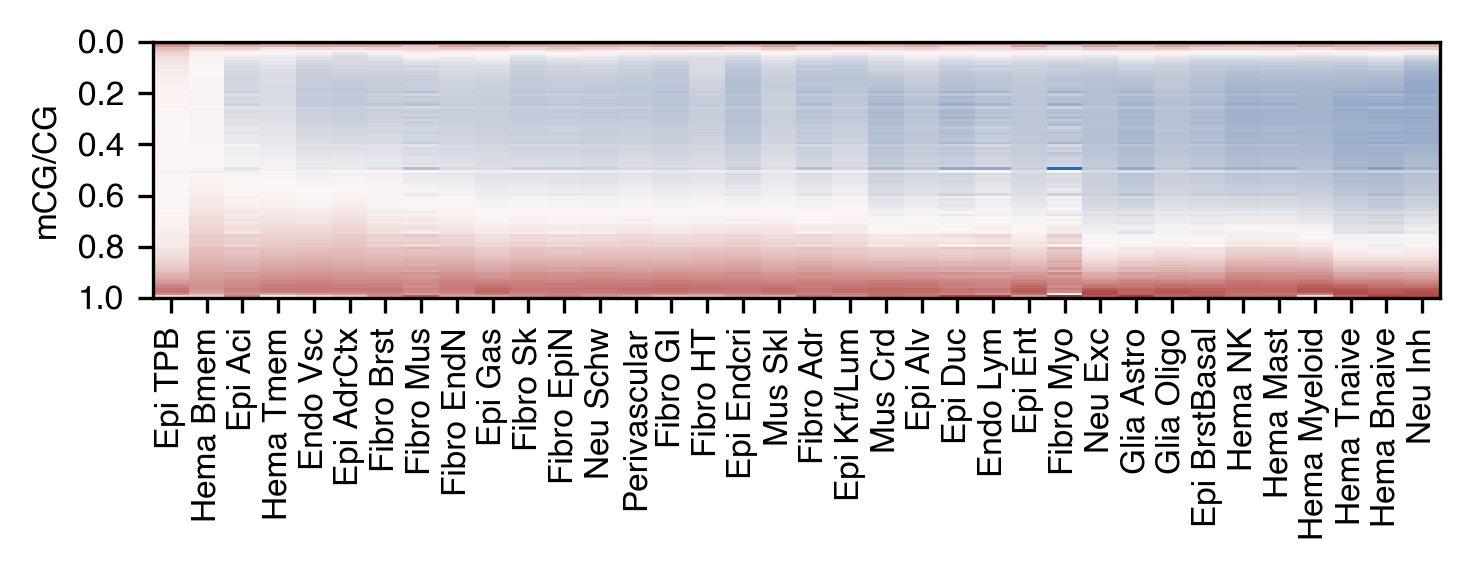

In [22]:
from scipy.stats import zscore
fig, ax = plt.subplots(figsize=(5,2), dpi=300)
i = 0
res = 10
# data = pd.DataFrame([result[ct][i] for ct in L1_list], index=L1_list)
# vmax = np.percentile(data, 99)
ax.imshow(np.log1p(data[leg_order]), cmap='vlag', aspect='auto', interpolation='none')
ax.set_yticks(np.arange(0, 101, 20)-0.5)
ax.set_yticklabels(np.around(np.arange(0, 1.1, 0.2), decimals=1), fontsize=8)
ax.set_xticks(np.arange(len(L1_list)))
ax.set_xticklabels(leg_order.map(L1_annot), rotation=90, fontsize=8)
ax.set_ylabel('mCG/CG', fontsize=8)
fig.tight_layout()
fig.savefig('mCG_distribution/L1_siteCG_heatmap.pdf', transparent=True)


In [23]:
palette = sns.color_palette('rainbow_r', len(reslist))
xticks = np.array([0, 0.25, 0.5, 0.75, 1.0])
fig, axes = plt.subplots(9, 4, figsize=(6,9), dpi=300, sharex='all')
for i,ct in enumerate(leg_order):
    ax = axes.flatten()[i]
    ax.set_title(L1_annot[ct], fontsize=8)
    for k in range(10):
        ax.bar(np.arange(100), result[ct][k]/result[ct][k].sum()*100, 
               width=1, color=palette[k], alpha=0.2)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    ax.set_xticks(xticks*100)
    ax.set_xticklabels(xticks, fontsize=8)
    
fig.tight_layout()
fig.savefig('mCG_distribution/L1_siteCG_multires_hist.pdf', transparent=True)


In [24]:
import pysam

def load_allc(ct, chrom, start, end):
    global indir
    allc_path = f'{indir}merged_allc/L1/CGN/{ct}.CGN-Merge.allc.tsv.gz'
    idx, data_mc, data_cov = [], [], []
    with pysam.TabixFile(allc_path) as allc:
        allc_lines = allc.fetch(chrom, start, end)
        for line in allc_lines:
            _, pos, _, context, mc, cov, *_ = line.split("\t")
            pos, mc, cov = int(pos), int(mc), int(cov)
            idx.append(pos-start)
            data_mc.append(mc)
            data_cov.append(cov)
    return  np.array([idx, data_mc, data_cov])


In [25]:
chrom = 'chr2'
start = 70000000
end = 85000000
# chrom = 'chr14'
# start = 44000000
# end = 64000000

data_mc_row, data_mc_col, data_mc_data = [], [], []
data_cov_row, data_cov_col, data_cov_data = [], [], []
for i,ct in enumerate(leg_order):
    idx, tmp_mc, tmp_cov = load_allc(ct, chrom, start, end)
    posfilter = np.ones(len(idx)).astype(bool)
    for bed in rm_list:
        for xx,yy in bed[chrom]:
            posfilter[np.logical_and(idx>=xx, idx<=yy)] = False

    print(np.sum(posfilter)/len(posfilter))
    idx = idx[posfilter]
    tmp_mc = tmp_mc[posfilter]
    tmp_cov = tmp_cov[posfilter]
    data_mc_row.extend(np.zeros(len(idx))+i)
    data_mc_col.extend(idx)
    data_mc_data.extend(tmp_mc)
    data_cov_row.extend(np.zeros(len(idx))+i)
    data_cov_col.extend(idx)
    data_cov_data.extend(tmp_cov)
    print(ct)

data_mc = csr_matrix((data_mc_data, (data_mc_row, data_mc_col)), shape=[len(leg_order), end-start])
data_cov = csr_matrix((data_cov_data, (data_cov_row, data_cov_col)), shape=[len(leg_order), end-start])


In [26]:
order = {xx:yy for xx,yy in zip(leg_order, np.arange(len(leg_order)))}

In [27]:
def plot_track(ct, ymin, ax):
    mc_tmp = data_mc[order[ct]].toarray()[0]
    cov_tmp = data_cov[order[ct]].toarray()[0]
    # tmp = (data_mc.getrow(i).A1 / data_cov.getrow(i).A1).reshape((-1, res))
    # tmp = np.nanmean(tmp, axis=1)
    tmp = mc_tmp.reshape((-1, res)).sum(axis=1) / cov_tmp.reshape((-1, res)).sum(axis=1)
    x = np.arange(len(tmp))
    # ax.plot(x, tmp, linewidth=0.01)
    nbins = tmp.shape[0]
    ax.set_xlim([0, nbins])
    ax.set_ylim([ymin, 1.0])
    step = nbins//3
    ax.set_xticks(np.arange(0, nbins+1, step))
    ax.set_xticklabels([f'{xx//1e6}M' for xx in np.arange(start, end+1, step*res)], fontsize=10)
    ax.set_yticks([ymin, 1.0])
    # ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)
    ax.fill_between(x, tmp, ymin, where=tmp >= ymin, facecolor=L1_color[ct], interpolate=True)
    ax.set_title(L1_annot[ct], fontsize=10)
    sns.despine(ax=ax, right=False)
    return


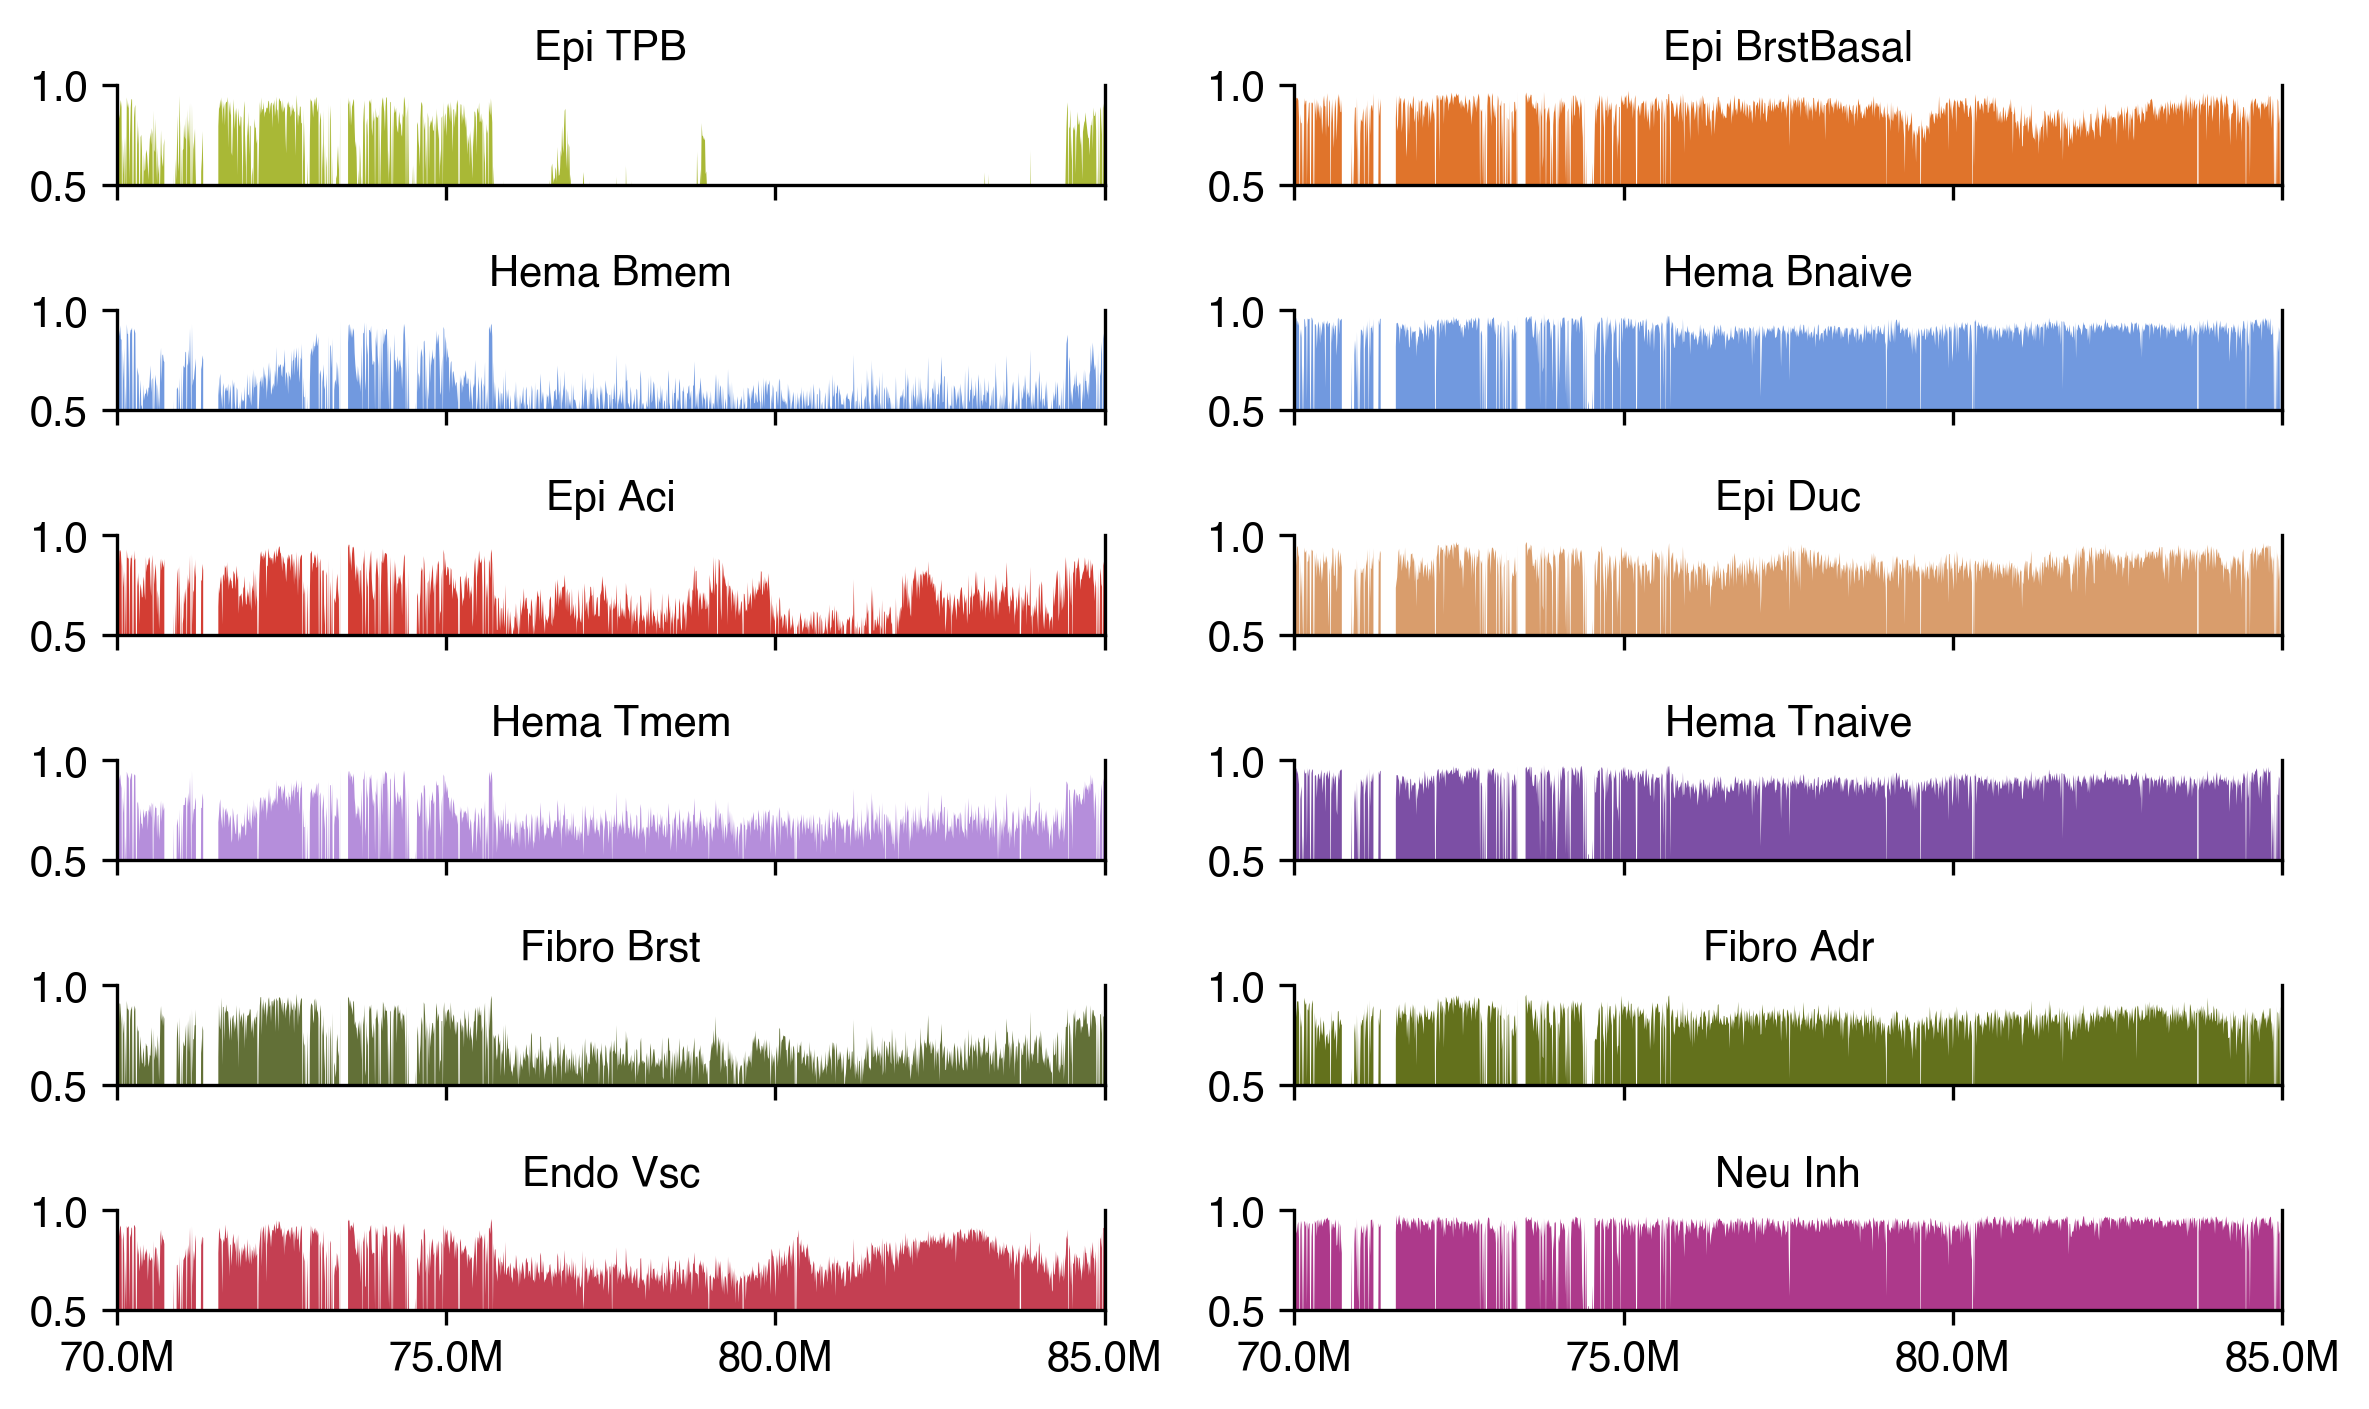

In [28]:
res = 10000
fig, axes = plt.subplots(6, 2, figsize=(8, 4.8), dpi=300, sharex='all')
for i,ct in enumerate(['c2','c35','c22','c1','c17','c3']):
    ax = axes[i,0]
    plot_track(ct, 0.5, ax)

for i,ct in enumerate(['c25','c36','c30','c15','c29','c16']):
    ax = axes[i,1]
    plot_track(ct, 0.5, ax)
    
fig.tight_layout()
fig.savefig('mCG_distribution/L1_track.pdf', transparent=True)


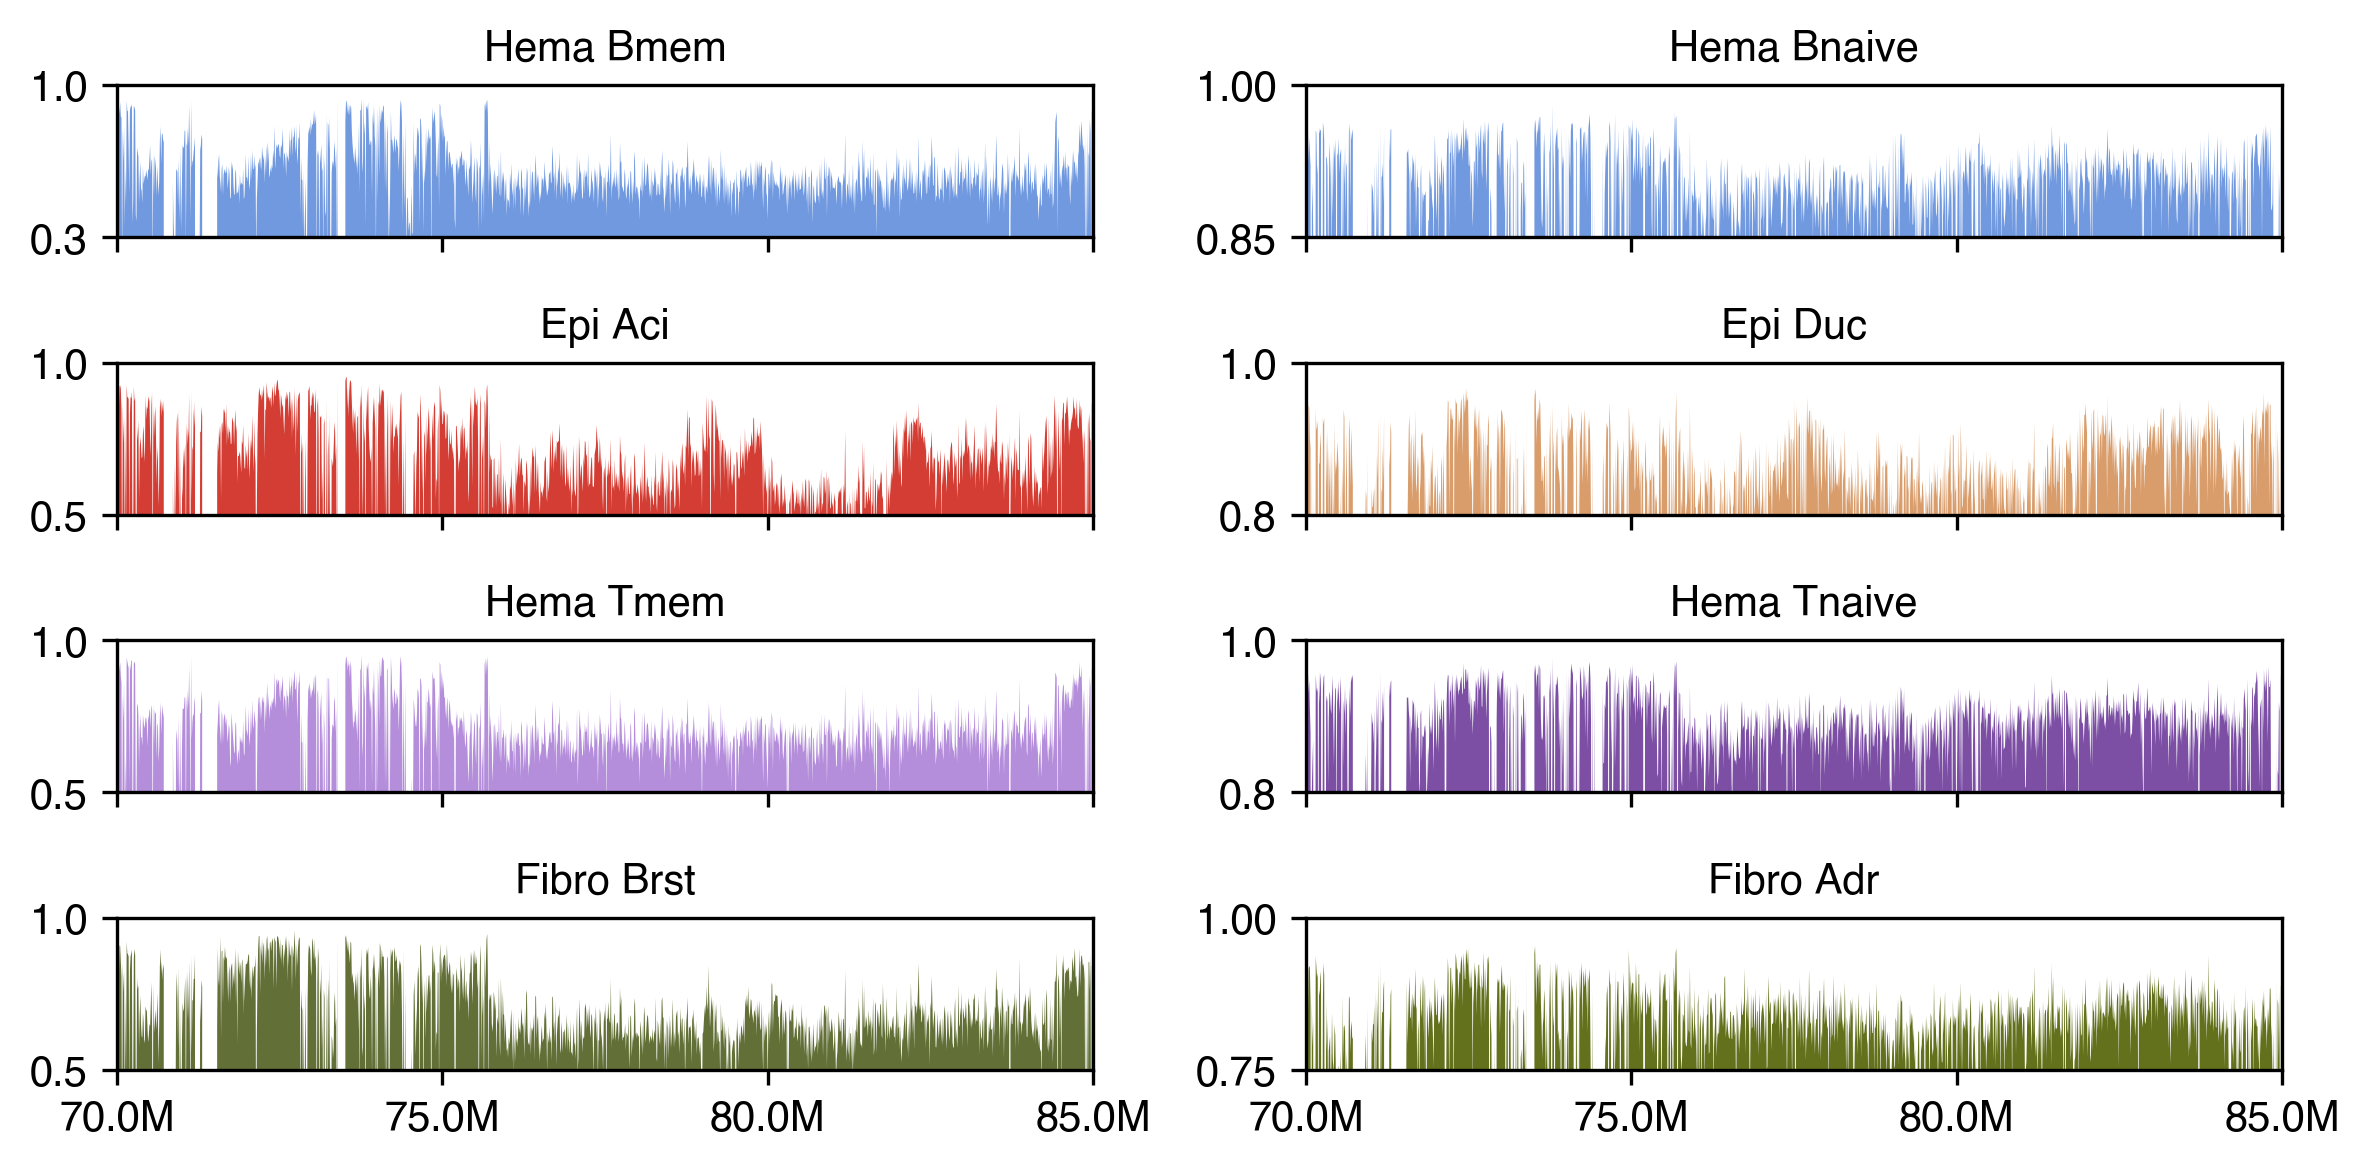

In [29]:
res = 10000
fig, axes = plt.subplots(4, 2, figsize=(8, 4), dpi=300, sharex='all')
for i,(ct,ymin) in enumerate(zip(['c35','c22','c1','c17'], [0.3, 0.5, 0.5, 0.5])):
    ax = axes[i,0]
    plot_track(ct, ymin, ax)

for i,(ct,ymin) in enumerate(zip(['c36','c30','c15','c29'], [0.85, 0.8, 0.8, 0.75])):
    ax = axes[i,1]
    plot_track(ct, ymin, ax)
    
fig.tight_layout()
fig.savefig('mCG_distribution/L1_track_ylim.pdf', transparent=True)
